# 02 – Capacity Analysis

This notebook analyzes product loading capacity based on two operational constraints:

1. Vehicle volume capacity  
2. Vehicle weight capacity  

The analysis identifies the maximum feasible loading quantity and determines the primary limiting factor (volume or weight) for each product.

### Parameters

In [1]:
VOLUME_CAPACITY = 18.5
WEIGHT_CAPACITY = 2.0

### Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
file_path = "../data/raw/main.xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="Data"
)

df = df.rename(columns={
    "عنوان گروه ارسال کالا": "shipping_group",
    "کد گروه ارسال کالا": "shipping_group_code",
    "کد کالا": "product_code",
    "نام کالا": "product_name",
    "گروه محصول": "product_group",
    "حجم": "volume_m3",
    "تناژ": "weight_ton"
})

df = df[[
    "shipping_group",
    "shipping_group_code",
    "product_code",
    "product_name",
    "product_group",
    "volume_m3",
    "weight_ton"
]].copy()

df["volume_m3"] = pd.to_numeric(
    df["volume_m3"],
    errors="coerce"
).fillna(0)

df["weight_ton"] = pd.to_numeric(
    df["weight_ton"],
    errors="coerce"
).fillna(0)

### Remove Invalid Products

In [4]:
df = df[
    ~(
        (df["volume_m3"] <= 0) &
        (df["weight_ton"] <= 0)
    )
].copy()

### Quantity by Volume

In [5]:
df["quantity_by_volume"] = np.where(
    df["volume_m3"] > 0,
    VOLUME_CAPACITY / df["volume_m3"],
    np.inf
)

### Quantity by Weight

In [6]:
df["quantity_by_weight"] = np.where(
    df["weight_ton"] > 0,
    WEIGHT_CAPACITY / df["weight_ton"],
    np.inf
)

### Final Quantity

In [7]:
df["final_qty"] = np.minimum(
    df["quantity_by_volume"],
    df["quantity_by_weight"]
)

df["final_qty"] = df["final_qty"].replace(
    np.inf,
    np.nan
)

### Loaded Weight

In [8]:
df["loaded_weight_ton"] = (
    df["final_qty"] *
    df["weight_ton"]
).clip(
    upper=WEIGHT_CAPACITY
)

### Limiting Factor

In [9]:
df["limiting_factor"] = np.where(
    df["volume_m3"] <= 0,
    "weight",
    np.where(
        df["weight_ton"] <= 0,
        "volume",
        np.where(
            df["quantity_by_volume"]
            <= df["quantity_by_weight"],
            "volume",
            "weight"
        )
    )
)

### Result

In [10]:
capacity_result = df[[
    "shipping_group",
    "shipping_group_code",
    "product_code",
    "product_name",
    "product_group",
    "volume_m3",
    "weight_ton",
    "quantity_by_volume",
    "quantity_by_weight",
    "final_qty",
    "loaded_weight_ton",
    "limiting_factor"
]]

capacity_result.head(20)

,shipping_group,shipping_group_code,product_code,product_name,product_group,volume_m3,weight_ton,quantity_by_volume,quantity_by_weight,final_qty,loaded_weight_ton,limiting_factor
0,"60 , 50 , 40 GSS0",241128,301010600002,RCWW045PAAA,Chiller Compressor,7.000000,0.0000,2.642857,inf,2.642857,0.000000,volume
1,"60 , 50 , 40 GSS0",241128,302010200009,GVM-H125USGSJ,Outdoor,0.061985,0.0850,298.459305,23.529412,23.529412,2.000000,weight
2,9000 IN & OD,241101,301010100056,OD TNUC0908TOO,Outdoor,1.032000,0.0600,17.926357,33.333333,17.926357,1.075581,volume
3,9000 IN & OD,241101,301010200031,ARNU07GBHA4,Indoor,0.208824,0.0310,88.591350,64.516129,64.516129,2.000000,weight
4,9000 IN & OD,241101,301010200033,ARNU09GTRC2,Indoor,0.122801,0.0000,150.650239,inf,150.650239,0.000000,volume
5,9000 IN & OD,241101,301010200034,ARNU09GTUC4,Indoor,0.157317,0.0000,117.596954,inf,117.596954,0.000000,volume
6,9000 IN & OD,241101,301010200035,ARNU09GBHA4,Indoor,0.215914,0.0000,85.682262,inf,85.682262,0.000000,volume
7,9000 IN & OD,241101,301010200036,ARNU09GL1G4,Indoor,0.171672,0.0215,107.763642,93.023256,93.023256,2.000000,weight
8,9000 IN & OD,241101,301010200037,ARNU09GSJN4/,Indoor,0.086775,0.0000,213.195045,inf,213.195045,0.000000,volume
9,9000 IN & OD,241101,301010200038,ARNU09GM1A4,Indoor,0.300300,0.0310,61.605062,64.516129,61.605062,1.909757,volume


### Limiting Factor Analysis

In [11]:
limiting_summary = (
    df["limiting_factor"]
    .value_counts()
)

limiting_summary

limiting_factor
volume    8356
weight    5156
Name: count, dtype: int64

### Limiting Factor%

In [12]:
limiting_percentage = (
    df["limiting_factor"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

limiting_percentage

limiting_factor
volume    61.84
weight    38.16
Name: proportion, dtype: float64

### Visualization

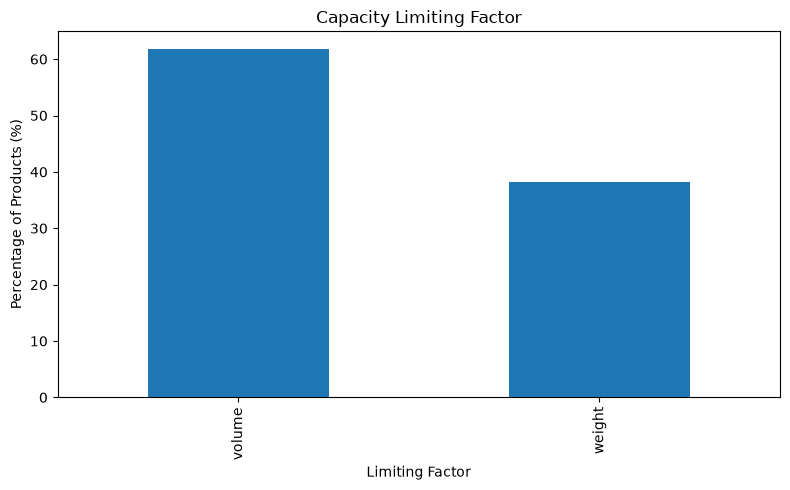

In [13]:
limiting_percentage.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Capacity Limiting Factor")
plt.xlabel("Limiting Factor")
plt.ylabel("Percentage of Products (%)")

plt.tight_layout()

plt.savefig(
    "../results/figures/capacity_limiting_factor.png",
    dpi=300
)

plt.show()

### Shipping Group Capacity

In [14]:
group_capacity = (
    df
    .groupby(
        ["shipping_group", "shipping_group_code"],
        as_index=False
    )
    .agg(
        products=("product_code", "nunique"),
        median_loaded_weight=("loaded_weight_ton", "median"),
        max_loaded_weight=("loaded_weight_ton", "max")
    )
)

group_capacity

,shipping_group,shipping_group_code,products,median_loaded_weight,max_loaded_weight
0,"60 , 50 , 40 GSS0",241128,2,1.0,2.0
1,9000 IN & OD,241101,53,2.0,2.0
2,AV Vid & Aud,241011,137,0.0,2.0
3,FDP Table,241015,208,0.0,2.0
4,Handsfree,241504,6,0.0,0.0
...,...,...,...,...,...
131,کمپرسور یخچال Accessories,2005,45,2.0,2.0
132,کمپرسور یخچال GITA (38),2006,3,2.0,2.0
133,کمپرسور یخچال Siberia,2002,28,2.0,2.0
134,کمپرسور یخچال مدل LG,2001,12,2.0,2.0


### Save Table

In [15]:
capacity_result.to_csv(
    "../results/tables/product_capacity_analysis.csv",
    index=False
)

group_capacity.to_csv(
    "../results/tables/shipping_group_capacity_summary.csv",
    index=False
)